In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv('fifa_league_21_train.csv')


In [3]:
type(df)

pandas.core.frame.DataFrame

In [4]:
#NOTE : counting total null values 
#   [df.isnull().sum() > 0]     ---> this provides boolean series like true and false of the each X(features) that contain null values.
#   df.isnull().sum()   ---> this counts total true and false after .isnull() checks any NaN
df.isnull().sum()[df.isnull().sum() > 0]

value_eur               1
pace                  170
shooting              170
passing               170
dribbling             170
defending             170
physic                170
goalkeeping_speed    1414
dtype: int64

In [5]:
#NOTE: interpolating missing values with polynomial
df['value_eur'] = df['value_eur'].interpolate(method='polynomial', order=2)

df['value_eur'].isna().sum()

np.int64(0)

In [6]:
#NOTE: for pace
df['pace'] = df['pace'].interpolate(method='polynomial', order=2)

df['pace'].isna().sum()

np.int64(0)

In [7]:
#NOTE: for shooting
df['shooting'] = df['shooting'].interpolate(method='polynomial', order=2)

df['shooting'].isna().sum()

np.int64(0)

In [8]:
#NOTE: for passing
df['passing'] = df['passing'].interpolate(method='polynomial', order=2)

df['passing'].isna().sum()

np.int64(0)

In [9]:
#NOTE: for dribbling
df['dribbling'] = df['dribbling'].interpolate(method='polynomial', order=2)
df['defending'] = df['defending'].interpolate(method='polynomial', order=2)
df['physic'] = df['physic'].interpolate(method='polynomial', order=2)
df['goalkeeping_speed'] = df['goalkeeping_speed'].interpolate(method='polynomial', order=2)

df.isna().sum().sum()

np.int64(7)

In [10]:
df.isnull().sum()[df.isnull().sum() > 0]

goalkeeping_speed    7
dtype: int64

In [11]:
#NOTE: since there is still 7 missing values in goadlkeepign....
# so now i will fill them with 0
df['goalkeeping_speed'] = df['goalkeeping_speed'].fillna(0)
df['goalkeeping_speed'].isna().sum()

np.int64(0)

In [12]:
type(df)

pandas.core.frame.DataFrame

In [13]:
df.isnull().sum()[df.isnull().sum() > 0]
#now we can see there is not missing values anymore

Series([], dtype: int64)

In [14]:
#NOTE : now checking features correlation with target values for feature selection .
#NOTE: using AI we found some features that need to be removed 
drop_cols = [
    'short_name','league_name','preferred_foot',
    'goalkeeping_diving','goalkeeping_handling','goalkeeping_kicking',
    'goalkeeping_positioning','goalkeeping_reflexes','international_reputation','goalkeeping_speed',
    'ls','st','rs','lw','lf','cf','rf','rw',
    'lam','cam','ram','lm','lcm','cm','rcm','rm',
    'lwb','ldm','cdm','rdm','rwb','lb','rb','lcb','cb','rcb','gk'
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])
df.columns.tolist()


['overall',
 'potential',
 'value_eur',
 'wage_eur',
 'age',
 'club_name',
 'club_position',
 'weak_foot',
 'skill_moves',
 'pace',
 'shooting',
 'passing',
 'dribbling',
 'defending',
 'physic',
 'attacking_crossing',
 'attacking_finishing',
 'attacking_heading_accuracy',
 'attacking_short_passing',
 'attacking_volleys',
 'skill_dribbling',
 'skill_curve',
 'skill_fk_accuracy',
 'skill_long_passing',
 'skill_ball_control',
 'movement_acceleration',
 'movement_sprint_speed',
 'movement_agility',
 'movement_reactions',
 'movement_balance',
 'power_shot_power',
 'power_jumping',
 'power_stamina',
 'power_strength',
 'power_long_shots',
 'mentality_aggression',
 'mentality_interceptions',
 'mentality_positioning',
 'mentality_vision',
 'mentality_penalties',
 'mentality_composure',
 'defending_marking_awareness',
 'defending_standing_tackle',
 'defending_sliding_tackle',
 'position']

In [15]:
df

,overall,potential,value_eur,wage_eur,age,club_name,club_position,weak_foot,skill_moves,pace,...,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,position
0,93,93,103500000.0,560000.0,33,FC Barcelona,CAM,4,4,85.000000,...,44,40,93,95,75,96,32,35,24,3
1,92,92,63000000.0,220000.0,35,Juventus,LS,4,5,89.000000,...,63,29,95,82,84,95,28,32,24,4
2,91,91,111000000.0,240000.0,31,FC Bayern München,ST,4,4,78.000000,...,81,49,94,79,88,88,35,42,19,1
3,91,91,132000000.0,270000.0,28,Paris Saint-Germain,LW,5,5,91.000000,...,51,36,87,90,92,93,35,30,29,2
4,91,91,129000000.0,370000.0,29,Manchester City,RCM,5,4,76.000000,...,76,66,88,94,84,91,68,65,53,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579,55,68,300000.0,2000.0,19,Eintracht Frankfurt,RES,3,2,60.000000,...,61,49,46,59,49,46,51,58,57,5
1580,54,65,240000.0,4000.0,22,LOSC Lille,RES,2,3,61.000000,...,44,22,46,51,44,61,29,29,41,1
1581,54,74,275000.0,550.0,18,RB Leipzig,RES,2,1,52.497705,...,28,12,5,26,18,31,9,10,14,2
1582,52,73,240000.0,500.0,17,U.S. Sassuolo Calcio,RES,3,2,47.000000,...,45,54,21,34,37,48,53,55,52,8


In [16]:
#NOTE: checking all the names of club
print(df['club_name'].unique())
df['club_name'] = df['club_name'].str.strip().str.capitalize()

['FC Barcelona' 'Juventus' 'FC Bayern München' 'Paris Saint-Germain'
 'Manchester City' 'Atlético de Madrid' 'Liverpool' 'Real Madrid CF'
 'Inter' 'Napoli' 'Tottenham Hotspur' 'Chelsea' 'Arsenal' 'Lazio'
 'Manchester United' 'Borussia Dortmund' 'Atalanta' 'Real Sociedad'
 'Borussia Mönchengladbach' 'Leicester City' 'RB Leipzig' 'Villarreal CF'
 'Olympique Lyonnais' 'AC Milan' 'Sevilla FC' 'RC Celta de Vigo'
 'AS Monaco' 'Everton' 'Olympique de Marseille' 'Roma'
 'Athletic Club de Bilbao' 'Eintracht Frankfurt' 'Bayer 04 Leverkusen'
 'VfL Wolfsburg' 'Real Betis Balompié' 'Leeds United' 'LOSC Lille'
 'U.S. Sassuolo Calcio' 'West Ham United' '1. FC Union Berlin' 'OGC Nice'
 'Stade Rennais FC' 'U.C. Sampdoria' 'Montpellier Hérault SC' 'Granada CF'
 'Sport-Club Freiburg' 'Hellas Verona' 'FC Metz' 'Racing Club de Lens'
 'VfB Stuttgart']


In [17]:

print(f"total unique clubs in the dataset is : {df['club_name'].nunique()}")

total unique clubs in the dataset is : 50


In [18]:
#NOTE : Feature labelling 
df.rename(columns={
    'value_eur':'player_market_value_inEuro',
    'wage_eur' : 'player_salary_inEuro',
    'club_position':'Player_club_pos',
    'weak_foot':'weak_foot_points',
}, inplace=True)
df

,overall,potential,player_market_value_inEuro,player_salary_inEuro,age,club_name,Player_club_pos,weak_foot_points,skill_moves,pace,...,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,position
0,93,93,103500000.0,560000.0,33,Fc barcelona,CAM,4,4,85.000000,...,44,40,93,95,75,96,32,35,24,3
1,92,92,63000000.0,220000.0,35,Juventus,LS,4,5,89.000000,...,63,29,95,82,84,95,28,32,24,4
2,91,91,111000000.0,240000.0,31,Fc bayern münchen,ST,4,4,78.000000,...,81,49,94,79,88,88,35,42,19,1
3,91,91,132000000.0,270000.0,28,Paris saint-germain,LW,5,5,91.000000,...,51,36,87,90,92,93,35,30,29,2
4,91,91,129000000.0,370000.0,29,Manchester city,RCM,5,4,76.000000,...,76,66,88,94,84,91,68,65,53,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579,55,68,300000.0,2000.0,19,Eintracht frankfurt,RES,3,2,60.000000,...,61,49,46,59,49,46,51,58,57,5
1580,54,65,240000.0,4000.0,22,Losc lille,RES,2,3,61.000000,...,44,22,46,51,44,61,29,29,41,1
1581,54,74,275000.0,550.0,18,Rb leipzig,RES,2,1,52.497705,...,28,12,5,26,18,31,9,10,14,2
1582,52,73,240000.0,500.0,17,U.s. sassuolo calcio,RES,3,2,47.000000,...,45,54,21,34,37,48,53,55,52,8


In [19]:
#NOTE: checking if any categorical data exists
df.iloc[0:44]

,overall,potential,player_market_value_inEuro,player_salary_inEuro,age,club_name,Player_club_pos,weak_foot_points,skill_moves,pace,...,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,position
0,93,93,103500000.0,560000.0,33,Fc barcelona,CAM,4,4,85.000000,...,44,40,93,95,75,96,32,35,24,3
1,92,92,63000000.0,220000.0,35,Juventus,LS,4,5,89.000000,...,63,29,95,82,84,95,28,32,24,4
2,91,91,111000000.0,240000.0,31,Fc bayern münchen,ST,4,4,78.000000,...,81,49,94,79,88,88,35,42,19,1
3,91,91,132000000.0,270000.0,28,Paris saint-germain,LW,5,5,91.000000,...,51,36,87,90,92,93,35,30,29,2
4,91,91,129000000.0,370000.0,29,Manchester city,RCM,5,4,76.000000,...,76,66,88,94,84,91,68,65,53,1
5,91,93,120000000.0,125000.0,27,Atlético de madrid,GK,3,1,64.777272,...,34,19,11,65,11,68,27,12,18,1
6,90,93,110000000.0,260000.0,28,Fc barcelona,GK,4,1,64.595348,...,43,22,11,70,25,70,25,13,10,3
7,90,91,113000000.0,210000.0,28,Liverpool,LCB,3,2,76.000000,...,83,90,47,65,62,90,93,93,86,3
8,90,90,120500000.0,250000.0,28,Liverpool,LW,4,4,94.000000,...,75,35,92,85,71,84,42,42,38,3
9,90,90,120500000.0,250000.0,28,Liverpool,RW,3,4,93.000000,...,63,55,91,84,83,90,38,43,41,3


# since player_club_pos doesn't make any effect in club position rather players_quality matter's so dropping this feature

In [20]:
df.drop(columns=['Player_club_pos'] , inplace=True)
df

,overall,potential,player_market_value_inEuro,player_salary_inEuro,age,club_name,weak_foot_points,skill_moves,pace,shooting,...,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,position
0,93,93,103500000.0,560000.0,33,Fc barcelona,4,4,85.000000,92.000000,...,44,40,93,95,75,96,32,35,24,3
1,92,92,63000000.0,220000.0,35,Juventus,4,5,89.000000,93.000000,...,63,29,95,82,84,95,28,32,24,4
2,91,91,111000000.0,240000.0,31,Fc bayern münchen,4,4,78.000000,91.000000,...,81,49,94,79,88,88,35,42,19,1
3,91,91,132000000.0,270000.0,28,Paris saint-germain,5,5,91.000000,85.000000,...,51,36,87,90,92,93,35,30,29,2
4,91,91,129000000.0,370000.0,29,Manchester city,5,4,76.000000,86.000000,...,76,66,88,94,84,91,68,65,53,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579,55,68,300000.0,2000.0,19,Eintracht frankfurt,3,2,60.000000,47.000000,...,61,49,46,59,49,46,51,58,57,5
1580,54,65,240000.0,4000.0,22,Losc lille,2,3,61.000000,43.000000,...,44,22,46,51,44,61,29,29,41,1
1581,54,74,275000.0,550.0,18,Rb leipzig,2,1,52.497705,31.188276,...,28,12,5,26,18,31,9,10,14,2
1582,52,73,240000.0,500.0,17,U.s. sassuolo calcio,3,2,47.000000,23.000000,...,45,54,21,34,37,48,53,55,52,8


In [21]:
#NOTE :arrgregrating all features of each players against the same club
#--> to make each players rating into a whole club's quality which matter's for club position

# Using a dictionary to tell Pandas exactly which math to use for each column
# 1. Group the detailed features into a list for easy processing
technical_skills = [
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 
    'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 
    'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
    'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 
    'movement_reactions', 'movement_balance', 'power_shot_power', 
    'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 
    'mentality_vision', 'mentality_penalties', 'mentality_composure', 
    'defending_marking_awareness', 'defending_standing_tackle', 'defending_sliding_tackle'
]

# 2. Define the aggregation dictionary
agg_logic = {
    'overall': ['median', 'max'],
    'potential': ['median', 'max'],
    'player_market_value_inEuro': 'sum',
    'player_salary_inEuro': 'sum',
    'age': 'mean',
    'weak_foot_points': 'median',
    'skill_moves': 'median',
    'position': 'median'  # This is your Target (y)
}

# 3. Add all technical skills to the dictionary with 'median' -- which focus on consistency 
for skill in technical_skills:
    agg_logic[skill] = 'median'

# 4. Perform the aggregation
# club_name will become the index
club_level_df = df.groupby('club_name').aggregate(agg_logic)

# 5. Flatten the columns for your Heatmap (e.g., 'overall_median', 'overall_max')
club_level_df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in club_level_df.columns]



In [22]:
club_level_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, 1. fc union berlin to West ham united
Data columns (total 41 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   overall_median                      50 non-null     float64
 1   overall_max                         50 non-null     int64  
 2   potential_median                    50 non-null     float64
 3   potential_max                       50 non-null     int64  
 4   player_market_value_inEuro_sum      50 non-null     float64
 5   player_salary_inEuro_sum            50 non-null     float64
 6   age_mean                            50 non-null     float64
 7   weak_foot_points_median             50 non-null     float64
 8   skill_moves_median                  50 non-null     float64
 9   position_median                     50 non-null     float64
 10  pace_median                         50 non-null     float64
 11  shooting_median       

In [23]:
#NOTE : first 10 column
col_chunck_one = club_level_df.iloc[0:1, 0:10]
col_chunck_one.columns.value_counts()    #This tells name of first_ten_features 0 to 9

overall_median                    1
overall_max                       1
potential_median                  1
potential_max                     1
player_market_value_inEuro_sum    1
player_salary_inEuro_sum          1
age_mean                          1
weak_foot_points_median           1
skill_moves_median                1
position_median                   1
Name: count, dtype: int64

In [24]:
#NOTE : other 10 column
col_chunck_two = club_level_df.iloc[0:1, 10:21]
col_chunck_two.columns.value_counts()    #This tells name of other_ten_features 10 to 21

pace_median                          1
shooting_median                      1
passing_median                       1
dribbling_median                     1
defending_median                     1
physic_median                        1
attacking_crossing_median            1
attacking_finishing_median           1
attacking_heading_accuracy_median    1
attacking_short_passing_median       1
attacking_volleys_median             1
Name: count, dtype: int64

In [25]:
#NOTE :  mid ten columns
col_chunck_three = club_level_df.iloc[0:1, 21:31]
col_chunck_three.columns.value_counts()    #This tells name of mid_ten_features 21 to 31

skill_dribbling_median          1
skill_curve_median              1
skill_fk_accuracy_median        1
skill_long_passing_median       1
skill_ball_control_median       1
movement_acceleration_median    1
movement_sprint_speed_median    1
movement_agility_median         1
movement_reactions_median       1
movement_balance_median         1
Name: count, dtype: int64

In [26]:
#NOTE :  last ten columns
col_chunck_four = club_level_df.iloc[0:1, 31:]
col_chunck_four.columns.value_counts()    #This tells name of mid_ten_features 31 to last

power_shot_power_median               1
mentality_aggression_median           1
mentality_interceptions_median        1
mentality_positioning_median          1
mentality_vision_median               1
mentality_penalties_median            1
mentality_composure_median            1
defending_marking_awareness_median    1
defending_standing_tackle_median      1
defending_sliding_tackle_median       1
Name: count, dtype: int64

# NOTE: now checking the importance of rest of 41 columns using [correlation]

# The Result: As your team's overall_median goes UP, the position_median goes DOWN (toward 1st place).

# Feature	  Correlation Strength	Meaning
overall_median	-0.89	   ----     Extreme	This is your #1 predictor. The quality of the "core" squad 
                                    almost perfectly dictates the final rank.

overall_max	    -0.87       -----	Very Strong	Having a superstar is nearly as important as the average squad quality.

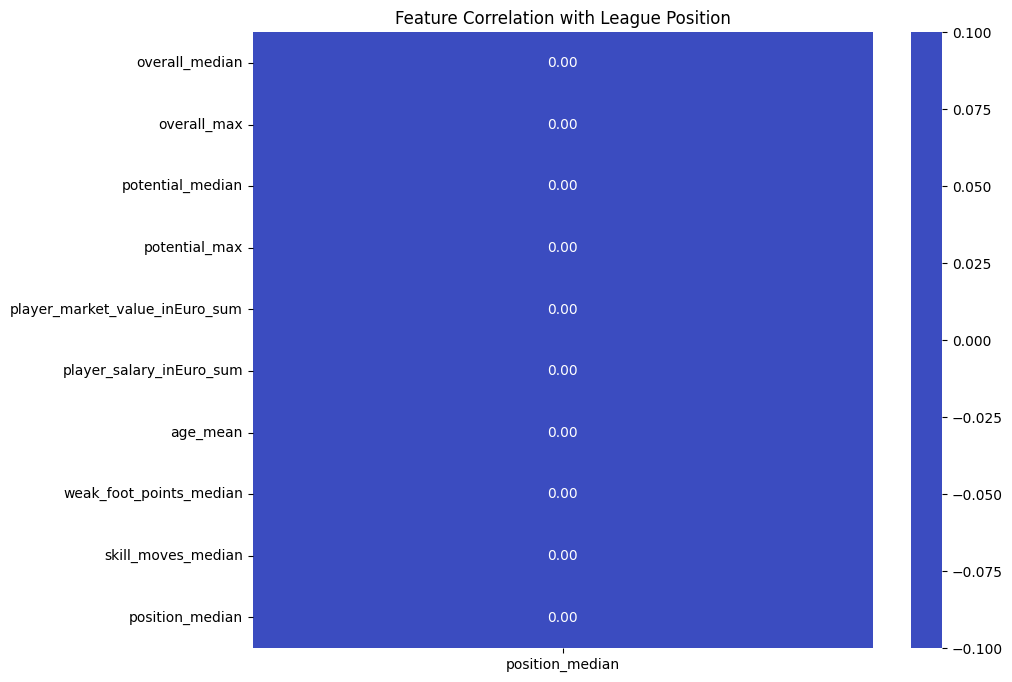

In [27]:
# 1. Calculate the correlation matrix
# 2. Select ONLY the 'club_position' column
# 3. Sort the values so the strongest predictors are at the top
# 4. FILL THE NaNs WITH 0 (This stops the warning)
target_corr = col_chunck_one.corr()[['position_median']].fillna(0).sort_values(by='position_median')

# 4. Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(target_corr, 
            annot=True, 
            cmap='coolwarm', # I recommend coolwarm to see the blue/red contrast
            fmt='.2f', 
            center=0)

plt.title('Feature Correlation with League Position')
plt.show()
